<a href="https://colab.research.google.com/github/alihuss1017/VAE-for-X-Rays/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Configuring device to CUDA

In [1]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() == True else 'cpu')

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [3]:
import os
import shutil

src_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/train'
dst_dir = '/content/data'

os.makedirs(dst_dir, exist_ok=True)

# Copy each subfolder (NORMAL, PNEUMONIA) into dst_dir
for folder_name in os.listdir(src_dir):
    src_subfolder = os.path.join(src_dir, folder_name)
    dst_subfolder = os.path.join(dst_dir, folder_name)

    if os.path.isdir(src_subfolder):
        shutil.copytree(src_subfolder, dst_subfolder)

print("Subfolders copied to:", dst_dir)


Subfolders copied to: /content/data


### Setting up dataloaders

In [4]:
import torchvision.transforms as transforms
import torchvision.datasets as dataset
from torch.utils.data import DataLoader

# Resizing and tensorizing images for training purposes
xray_data = dataset.ImageFolder(root = '/content/data',
                                     transform = transforms.Compose([
                                         transforms.Resize(64),
                                         transforms.CenterCrop(64),
                                         transforms.ToTensor(),
                                     ]))

class IgnoreLabelsDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __getitem__(self, index):
        image, _ = self.dataset[index]
        return image

    def __len__(self):
        return len(self.dataset)


xray_data = IgnoreLabelsDataset(xray_data)
# train-test split
train_size = int(.7 * len(xray_data))
test_size = len(xray_data) - train_size

train_set, test_set = torch.utils.data.random_split(xray_data, [train_size, test_size])
train_loader = DataLoader(train_set, batch_size = 128, shuffle = True, drop_last = True)
test_loader = DataLoader(test_set, batch_size = 128, shuffle = True, drop_last = True)

### Visualzing Training Images

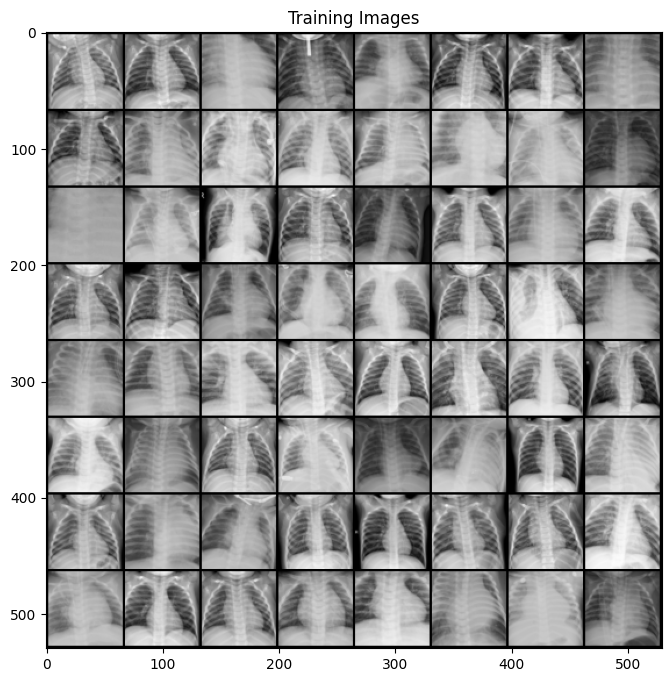

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision.utils as vutils

plt.figure(figsize = (8, 8))
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(next(iter(train_loader))[:64], padding = 2, normalize = True).cpu(), (1, 2, 0)))

### Defining the VAE model

In [12]:
import torch.nn as nn
import torch.nn.functional as F

class ConvEncoder(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 4, 2, 1)
        self.conv2 = nn.Conv2d(32, 64, 4, 2, 1)
        self.conv3 = nn.Conv2d(64, 128, 4, 2, 1)
        self.conv4 = nn.Conv2d(128, 256, 4, 2, 1)

        self.fc_mu = nn.Linear(256 * 4 * 4, z_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, z_dim)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar


In [13]:
def reparametrize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

In [14]:
class ConvDecoder(nn.Module):
    def __init__(self, z_dim=20):
        super().__init__()
        self.fc = nn.Linear(z_dim, 128 * 4 * 4)

        self.deconv1 = nn.ConvTranspose2d(128, 64, 4, 2, 1)
        self.deconv2 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.deconv3 = nn.ConvTranspose2d(32, 16, 4, 2, 1)
        self.deconv4 = nn.ConvTranspose2d(16, 3, 4, 2, 1)

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 128, 4, 4)
        x = F.relu(self.deconv1(x))
        x = F.relu(self.deconv2(x))
        x = F.relu(self.deconv3(x))
        x = torch.sigmoid(self.deconv4(x))
        return x

In [15]:
class VAE(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.encoder = ConvEncoder(z_dim)
        self.decoder = ConvDecoder(z_dim)

    def forward(self, x):
      mu, logvar = self.encoder(x)
      z = reparametrize(mu, logvar)
      x_hat = self.decoder(z)
      return x_hat, mu, logvar

### VAE Loss Function

In [16]:
def vae_loss(x_recon, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div

### Training VAE

In [17]:
vae = VAE(z_dim=100).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
losses = []

for epoch in range(50):
    vae.train()
    total_loss = 0
    for x in train_loader:
        x = x.to(device)
        x_recon, mu, logvar = vae(x)
        loss = vae_loss(x_recon, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    losses.append(total_loss / len(train_loader.dataset))
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader.dataset):.4f}")


Epoch 1, Loss: 8170.6537
Epoch 2, Loss: 7976.8562
Epoch 3, Loss: 7934.2657
Epoch 4, Loss: 7881.2976
Epoch 5, Loss: 7812.3182
Epoch 6, Loss: 7764.8685
Epoch 7, Loss: 7735.1351
Epoch 8, Loss: 7706.7495
Epoch 9, Loss: 7678.2888
Epoch 10, Loss: 7661.7704
Epoch 11, Loss: 7651.8654
Epoch 12, Loss: 7643.0445
Epoch 13, Loss: 7633.1768
Epoch 14, Loss: 7624.7946
Epoch 15, Loss: 7619.9878
Epoch 16, Loss: 7613.5206
Epoch 17, Loss: 7609.1703
Epoch 18, Loss: 7603.9158
Epoch 19, Loss: 7601.2210
Epoch 20, Loss: 7600.6997
Epoch 21, Loss: 7600.7354
Epoch 22, Loss: 7593.7805
Epoch 23, Loss: 7592.3846
Epoch 24, Loss: 7590.0724
Epoch 25, Loss: 7589.3348
Epoch 26, Loss: 7587.5374
Epoch 27, Loss: 7587.0852
Epoch 28, Loss: 7585.7111
Epoch 29, Loss: 7580.2143
Epoch 30, Loss: 7581.8093
Epoch 31, Loss: 7581.5323
Epoch 32, Loss: 7579.4132
Epoch 33, Loss: 7578.8688
Epoch 34, Loss: 7582.3981
Epoch 35, Loss: 7582.0717
Epoch 36, Loss: 7575.8522
Epoch 37, Loss: 7577.7332
Epoch 38, Loss: 7574.6920
Epoch 39, Loss: 7574.

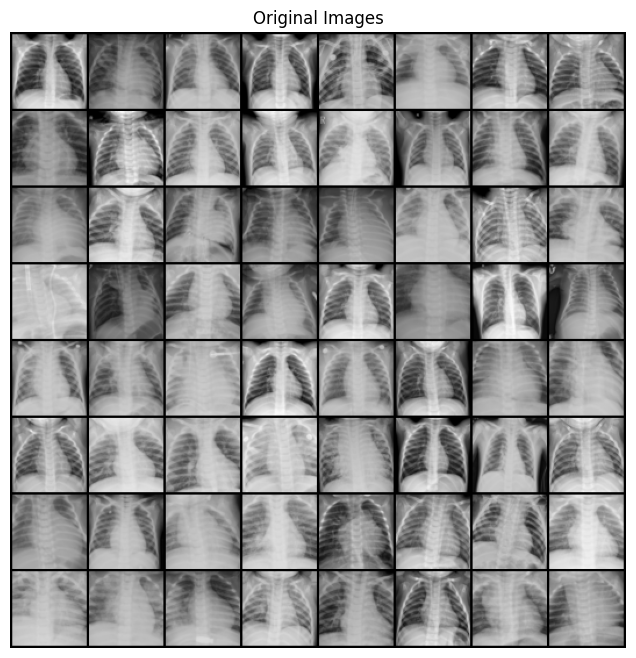

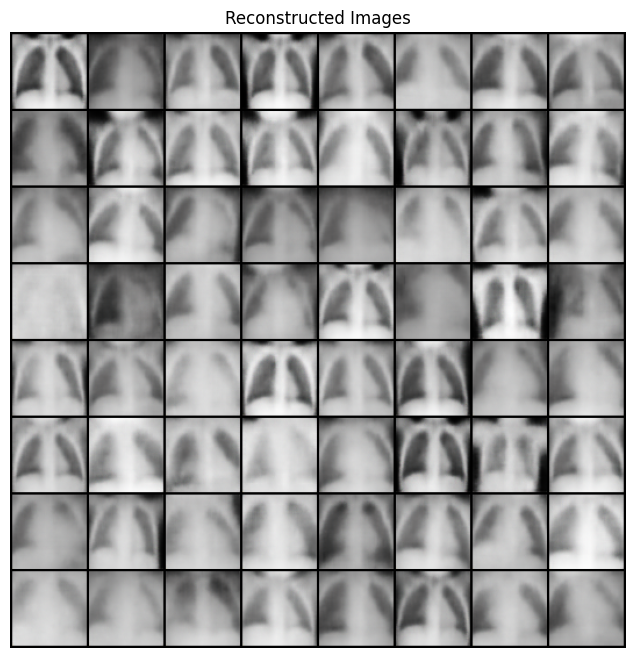

In [25]:
vae.eval()

with torch.no_grad():
    for x in test_loader:
        x = x.to(device)
        x_recon, _, _ = vae(x)
        break  # Only use first batch

# Unnormalize if needed (if your images are normalized in the transform)
def show_images(img_batch, title):
    grid = vutils.make_grid(img_batch.cpu()[:64], nrow=8, normalize=True)
    plt.figure(figsize=(8, 8))
    plt.title(title)
    plt.axis('off')
    plt.imshow(grid.permute(1, 2, 0))
    plt.show()

show_images(x, "Original Images")
show_images(x_recon, "Reconstructed Images")
